# 92 - Varyans ayrışımı ve kişi içi güvenilirlik

**İzole notebook.** Zincirin (01-06) hiçbir parçası bunu okumaz.

## Soru

Elimizde katılımcı × koşul tablosu var, 12 × 5 = 60 sayı. Hepsi birbirinden farklı.
**Bu farklılık nereden geliyor?** Üç kaynak mümkün:

1. **Kişi** - bazı insanlar dengelemede daha iyi
2. **Koşul** - gürültü seviyesi performansı etkiliyor
3. **Artık** - aynı kişi aynı koşulda her seferinde biraz farklı

Bu notebook üçünün payını ölçüyor, sonra da doğrudan bir tasarım sorusunu cevaplıyor:
**kişiye özel optimum gürültü seviyesi ölçülebilir bir şey mi?**

## Neden önemli

Pilotun amacı kişiye özel optimum seviyeyi bulmaktı ve belirgin fark çıkmadı. Ana deney için
gürültüsüz ile N2 arasını beşe bölmek düşünülüyor. Bu notebook o kararın önündeki asıl soruyu
ölçüyor: ölçüm zaten kişinin koşullarını ayırt edebiliyor mu?

## Yöntem

- **Varyans ayrışımı**: dengeli katılımcı × koşul tablosunda toplam kareler toplamını
  kişi / koşul / artık bileşenlerine ayırmak. Ek olarak ICC (intraclass correlation):
  ölçümün ne kadarı kişinin kalıcı özelliği.
- **Split-half güvenilirlik**: her katılımcının bir koşuldaki 10 denemesini rastgele 5+5
  bölüp iki yarıyı ayrı hesaplamak, sonra iki yarının birbirini tutup tutmadığına bakmak.
  200 rastgele bölünme.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Aktif veri seti. config.yaml -> datasets ile ayni isimler.
DATASET = "pilot1"

def _interim(dataset):
    for base in [Path.cwd(), *Path.cwd().parents]:
        p = base / "data" / dataset / "interim"
        if p.is_dir():
            return p
    raise FileNotFoundError(f"data/{dataset}/interim bulunamadi")

INTERIM = _interim(DATASET)
COND    = ["no_noise", "N1", "N2", "N3", "N4"]
N_SPLIT = 200          # split-half tekrar sayisi
SEED    = 0

INK, SIG, CTL, MUT = "#18222A", "#A94E08", "#155F5A", "#9AA6A2"
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("interim:", INTERIM)

interim: c:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\interim


## 1. Varyans ayrışımı

Dengeli bir katılımcı × koşul tablosunda (n kişi, k koşul) toplam kareler toplamı tam olarak
üçe ayrılır:

```
SS_toplam = SS_kisi + SS_kosul + SS_artik
```

- `SS_kisi`   : kişilerin kendi ortalamalarının genel ortalamadan sapması
- `SS_kosul`  : koşul ortalamalarının genel ortalamadan sapması
- `SS_artik`  : geri kalan; kişi × koşul etkileşimi ve ölçüm oynaması

**ICC** (intraclass correlation) ayrı bir soru soruyor: aynı kişiyi tekrar ölçsen aynı sayıyı
alır mısın? 1'e yakınsa ölçüm kişiyi güvenilir ayırıyor demektir.

Aynı kareler toplamından **repeated-measures ANOVA**'nın koşul F testi de doğrudan çıkıyor
(`F = MSc / MSr`). Bu bedava bir sağlama veriyor: NB06 non-parametrik testler kullandı, aynı
tabloda parametrik test ne diyor? Ek olarak kişi içi merkezlenmiş artıkların Shapiro-Wilk
normallik testi de raporlanıyor.

In [2]:
def decompose(W):
    """Dengeli kisi x kosul tablosunda varyans ayrisimi + ICC(2,1)."""
    X = W.values.astype(float)
    n, k = X.shape
    g = X.mean()
    SSp = k * ((X.mean(axis=1) - g) ** 2).sum()
    SSc = n * ((X.mean(axis=0) - g) ** 2).sum()
    SSt = ((X - g) ** 2).sum()
    SSr = SSt - SSp - SSc

    MSp = SSp / (n - 1)
    MSc = SSc / (k - 1)
    MSr = SSr / ((n - 1) * (k - 1))
    var_p = max((MSp - MSr) / k, 0.0)
    icc = var_p / (var_p + MSr) if (var_p + MSr) > 0 else np.nan

    # Ayni kareler toplamindan repeated-measures ANOVA'nin kosul F testi cikar.
    F = MSc / MSr if MSr > 0 else np.nan
    p_anova = float(stats.f.sf(F, k - 1, (n - 1) * (k - 1))) if np.isfinite(F) else np.nan
    # Friedman: karsilastirma icin, ayni tablo uzerinde
    p_fried = float(stats.friedmanchisquare(*X.T).pvalue)
    # normallik: kisi ici merkezlenmis artiklar
    resid = (X - X.mean(axis=1, keepdims=True)).ravel()
    p_shapiro = float(stats.shapiro(resid).pvalue)

    return dict(kisi_pct=100 * SSp / SSt, kosul_pct=100 * SSc / SSt,
                artik_pct=100 * SSr / SSt, ICC=icc,
                F_anova=F, p_anova=p_anova, p_friedman=p_fried,
                p_shapiro=p_shapiro, n=n, k=k)


def cell_table(df, metric, index="participant_id", col="noise_level_id"):
    return df.pivot(index=index, columns=col, values=metric)[COND].dropna()

In [3]:
tm = pd.read_parquet(INTERIM / "trial_metrics.parquet")
tm = tm[tm.noise_level_id.isin(COND)]

DEC = ["mae_angle_deg", "stab_time_s", "falls_angle_per_trial"]
dec_pc = tm.groupby(["participant_id", "noise_level_id"])[DEC].mean().reset_index()

tc = pd.read_parquet(INTERIM / "timing_cells.parquet")
tc = tc[tc.birim == "participant_x_condition"]
TIM = ["zc_ms", "variability", "var_norm", "amplitude"]

LABEL = {
    "mae_angle_deg":        "Ortalama |theta|",
    "stab_time_s":          "Stabilizasyon suresi",
    "falls_angle_per_trial":"Aci kaynakli dusus",
    "zc_ms":                "Action timing (zc_ms)",
    "variability":          "Action variability",
    "var_norm":             "Action var. (normalize)",
    "amplitude":            "Egri genligi",
}

rows = []
for m in DEC:
    rows.append(dict(olcut=LABEL[m], grup="karar metrigi", **decompose(cell_table(dec_pc, m))))
for m in TIM:
    rows.append(dict(olcut=LABEL[m], grup="action timing", **decompose(cell_table(tc, m))))

var = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print("VARYANS AYRISIMI\n")
print(var[["olcut", "grup", "kisi_pct", "kosul_pct", "artik_pct", "ICC"]]
      .round({"kisi_pct": 1, "kosul_pct": 1, "artik_pct": 1, "ICC": 2}).to_string(index=False))
print("\n\nSAGLAMA: parametrik vs non-parametrik, ayni tablo\n")
print(var[["olcut", "F_anova", "p_anova", "p_friedman", "p_shapiro"]]
      .round(4).to_string(index=False))

VARYANS AYRISIMI

                  olcut          grup  kisi_pct  kosul_pct  artik_pct  ICC
       Ortalama |theta| karar metrigi      89.4        4.0        6.6 0.91
   Stabilizasyon suresi karar metrigi      90.7        2.1        7.2 0.91
     Aci kaynakli dusus karar metrigi      96.8        0.7        2.5 0.97
  Action timing (zc_ms) action timing      86.3        0.5       13.2 0.83
     Action variability action timing      56.2        4.9       38.9 0.49
Action var. (normalize) action timing      69.9        0.8       29.3 0.63
           Egri genligi action timing      79.3        1.7       19.0 0.76


SAGLAMA: parametrik vs non-parametrik, ayni tablo

                  olcut  F_anova  p_anova  p_friedman  p_shapiro
       Ortalama |theta|   6.7124   0.0003      0.0014     0.9861
   Stabilizasyon suresi   3.1811   0.0222      0.0212     0.1537
     Aci kaynakli dusus   3.1584   0.0229      0.0051     0.0009
  Action timing (zc_ms)   0.4475   0.7736      0.8889     0.8657
    

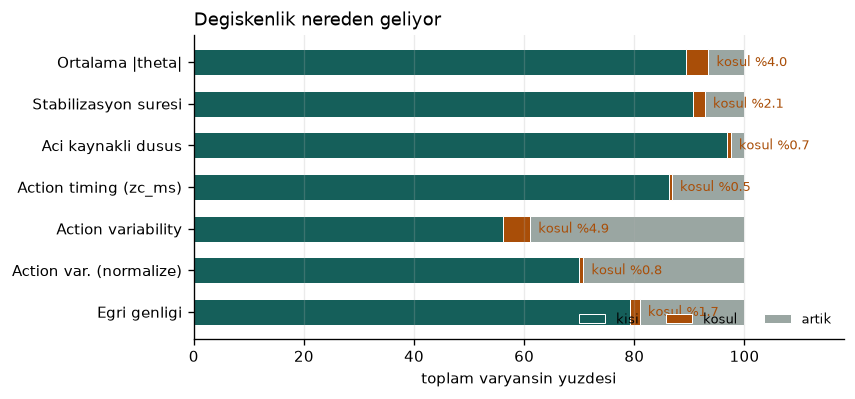

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
y = np.arange(len(var))[::-1]
left = np.zeros(len(var))
for col, color, lab in [("kisi_pct", CTL, "kisi"),
                        ("kosul_pct", SIG, "kosul"),
                        ("artik_pct", MUT, "artik")]:
    ax.barh(y, var[col], left=left, color=color, height=0.62,
            label=lab, edgecolor="white", linewidth=0.6)
    left = left + var[col].values
for i, (yy, v) in enumerate(zip(y, var.kosul_pct)):
    ax.text(var.kisi_pct.iloc[i] + v + 1.5, yy, f"kosul %{v:.1f}",
            va="center", fontsize=7.6, color=SIG)
ax.set_yticks(y, var.olcut)
ax.set_xlim(0, 118)
ax.set_xlabel("toplam varyansin yuzdesi")
ax.set_title("Degiskenlik nereden geliyor", loc="left")
ax.legend(frameon=False, ncol=3, fontsize=8, loc="lower right")
ax.grid(axis="y", visible=False)
fig.tight_layout()

**Okunuşu.** Bütün ölçütlerde değişkenliğin ezici çoğunluğu kişiden geliyor. Gürültü
koşulunun payı %0.5 ile %5 arasında.

Bunun iki sonucu var:

**Sağlama tablosu, ve `Yontem/06` §2'ye bir düzeltme.**

Üç karar metriği aynı davranmıyor:

- `mae_angle_deg` ve `stab_time_s`: artıklar Shapiro-Wilk'i geçiyor (p = 0.99 ve 0.15),
  RM-ANOVA ile Friedman neredeyse birebir aynı sonucu veriyor.
- `falls_angle_per_trial`: normallik **açıkça reddediliyor** (p = 0.0009). Şaşırtıcı değil,
  bu bir sayım değişkeni. Orada Friedman parametrik testten daha güçlü sonuç veriyor
  (p = 0.005 vs 0.023).

Yani NB06'nın non-parametrik tercihi **savunulabilir**: metriklerden biri gerçekten normal
değil ve üç metrik için tek bir test ailesinde kalmak tutarlı.

Ama `Yontem/06` §2'deki gerekçe cümlesi ("n = 12. Bu boyutta normallik varsayımı sınanamaz;
parametrik testler riskli") olduğu gibi doğru değil. Varsayım sınanabiliyor ve iki metrikte
geçiyor. Doğru gerekçe iki parçalı: sayım metriği normal değil, ve n = 12'de Shapiro'nun gücü
düşük olduğu için diğer ikisinde "reddedilmedi" ile "normal" aynı şey değil. Sonuç hiçbir
metrikte test ailesine bağlı olmadığı için karar etkilenmiyor.


1. **Within-subject tasarım zorunluydu.** Kişi farkı devreden çıkarılmasaydı, %4'lük bir
   koşul etkisi %89'luk kişi farkının altında görülemezdi ve yüzlerce katılımcı gerekirdi.
2. **Ölçüm sağlam.** ICC 0.83-0.97, yani aynı kişi tekrar ölçülse benzer sonuç çıkar. Null
   sonuç "ölçümümüz kötüydü"den değil, "etki küçük"ten geliyor.

Ama asıl kritik karşılaştırma şu: **koşul payı ile artık payı.** Ortalama |theta|'da koşul
%4.0, artık %6.6. Açı kaynaklı düşüşte koşul %0.7, artık %2.5. Artık koşuldan büyük.

Bu, bir kişinin koşul sıralamasının büyük ölçüde oynamadan ibaret olabileceği anlamına gelir.
Bir sonraki bölüm bunu doğrudan ölçüyor.

## 2. Split-half: kişinin koşul sıralaması güvenilir mi

Her katılımcının her koşuldaki 10 denemesini rastgele 5+5 böl. İki yarıdan iki ayrı
katılımcı × koşul tablosu çıkar. Aynı kişinin aynı verisi, sadece farklı denemeler.

İki soru:

- Kişinin **genel seviyesi** iki yarıda tutuyor mu? (5 koşulun ortalaması)
- Kişinin **koşul sıralaması** iki yarıda tutuyor mu?

İlki tutup ikincisi tutmuyorsa, ölçüm kişileri ayırabiliyor ama o kişinin koşullarını
ayıramıyor demektir.

In [5]:
def split_half(df, metric, seed):
    r = np.random.default_rng(seed)
    A, B = {}, {}
    for (p, c), g in df.groupby(["participant_id", "noise_level_id"]):
        v = g[metric].values
        idx = r.permutation(len(v))
        h = len(v) // 2
        A[(p, c)] = v[idx[:h]].mean()
        B[(p, c)] = v[idx[h:2 * h]].mean()
    a = pd.Series(A).unstack()[COND]
    b = pd.Series(B).unstack()[COND]
    return a, b


def split_half_stats(df, metric, n_rep=N_SPLIT, sign=-1):
    """sign=-1: dusuk deger iyi (en iyi = argmin). sign=+1: yuksek deger iyi.

    Bir kisinin bir yaridaki 5 kosul degeri tamamen ayni cikarsa Spearman
    tanimsiz olur (ornegin dusus sayisi hepsinde 0). O kisi o tekrarda
    siralama hesabindan dusulur; nan_pct bunun ne siklikta oldugunu sayar.
    """
    same, rho, rp, nan_n, tot_n = [], [], [], 0, 0
    best = np.argmin if sign < 0 else np.argmax
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for s in range(n_rep):
            a, b = split_half(df, metric, SEED + s)
            same.append((best(a.values, axis=1) == best(b.values, axis=1)).mean())
            r = np.array([stats.spearmanr(a.values[i], b.values[i]).statistic
                          for i in range(len(a))])
            nan_n += int(np.isnan(r).sum())
            tot_n += len(r)
            rho.append(np.nanmean(r) if np.isfinite(r).any() else np.nan)
            rp.append(stats.pearsonr(a.mean(axis=1), b.mean(axis=1)).statistic)
    return dict(olcut=LABEL[metric],
                genel_seviye_r=np.nanmean(rp),
                kosul_siralamasi_rho=np.nanmean(rho),
                ayni_en_iyi_pct=100 * np.mean(same),
                tanimsiz_pct=100 * nan_n / tot_n)


sh = pd.DataFrame([
    split_half_stats(tm, "mae_angle_deg", sign=-1),
    split_half_stats(tm, "stab_time_s", sign=+1),
    split_half_stats(tm, "falls_angle_per_trial", sign=-1),
])
print(f"Split-half, her kosulda 10 deneme 5+5 bolundu, {N_SPLIT} tekrar")
print(f"Sansa beklenen 'ayni en iyi' orani: %{100/len(COND):.0f}\n")
print(sh.round(2).to_string(index=False))
print()
print("tanimsiz_pct: kisinin 5 kosul degeri o yarida tamamen ayni cikip")
print("Spearman'in hesaplanamadigi durumlarin orani, orn. dusus sayisi hepsinde 0.")

Split-half, her kosulda 10 deneme 5+5 bolundu, 200 tekrar
Sansa beklenen 'ayni en iyi' orani: %20

               olcut  genel_seviye_r  kosul_siralamasi_rho  ayni_en_iyi_pct  tanimsiz_pct
    Ortalama |theta|            0.97                  0.15            29.00          0.00
Stabilizasyon suresi            0.97                  0.04            18.58          0.00
  Aci kaynakli dusus            0.99                 -0.02            35.08          9.54

tanimsiz_pct: kisinin 5 kosul degeri o yarida tamamen ayni cikip
Spearman'in hesaplanamadigi durumlarin orani, orn. dusus sayisi hepsinde 0.


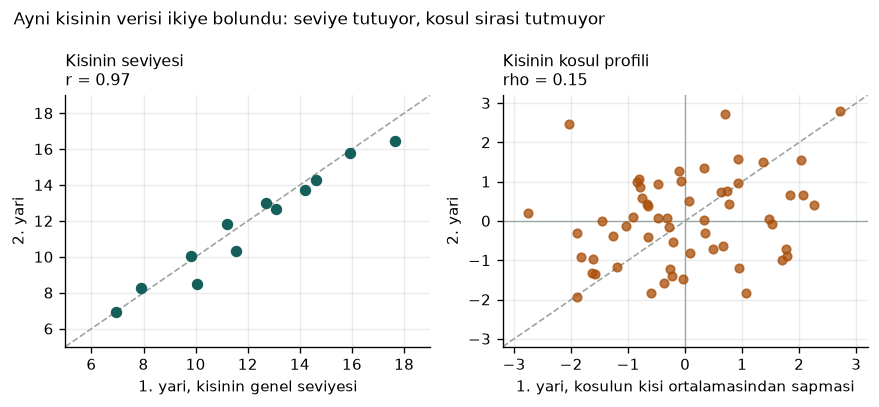

In [6]:
a, b = split_half(tm, "mae_angle_deg", SEED)

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.4))

ax = axes[0]
ax.scatter(a.mean(axis=1), b.mean(axis=1), s=34, color=CTL, zorder=3)
lo, hi = 5, 19
ax.plot([lo, hi], [lo, hi], color=MUT, lw=1, ls="--", zorder=1)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("1. yari, kisinin genel seviyesi")
ax.set_ylabel("2. yari")
ax.set_title(f"Kisinin seviyesi\nr = {sh.genel_seviye_r.iloc[0]:.2f}", loc="left", fontsize=9.5)

ax = axes[1]
da = (a.T - a.mean(axis=1)).T.values.ravel()
db = (b.T - b.mean(axis=1)).T.values.ravel()
ax.scatter(da, db, s=26, color=SIG, alpha=0.75, zorder=3)
ax.axhline(0, color=MUT, lw=0.8); ax.axvline(0, color=MUT, lw=0.8)
lim = 3.2
ax.plot([-lim, lim], [-lim, lim], color=MUT, lw=1, ls="--", zorder=1)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("1. yari, kosulun kisi ortalamasindan sapmasi")
ax.set_ylabel("2. yari")
ax.set_title(f"Kisinin kosul profili\nrho = {sh.kosul_siralamasi_rho.iloc[0]:.2f}",
             loc="left", fontsize=9.5)

fig.suptitle("Ayni kisinin verisi ikiye bolundu: seviye tutuyor, kosul sirasi tutmuyor",
             fontsize=10, x=0.02, ha="left")
fig.tight_layout()

**Sonuç net.**

Soldaki panel: kişinin genel seviyesi iki yarıda neredeyse mükemmel tutuyor (r ≈ 0.97).
Ölçüm, insanları birbirinden ayırmada çok güvenilir.

Sağdaki panel: aynı kişinin koşul profili tutmuyor (rho ≈ 0.15), nokta bulutu köşegenle
ilgisiz. Bir kişide "en iyi" çıkan koşul, aynı kişinin diğer yarısında sadece **%29** oranında
yine en iyi çıkıyor. Şansa %20 beklenir.

Yani ölçüm kötü değil. Ölçüm bu iş için yeterince hassas değil, çünkü ölçmeye çalıştığımız
kişi içi koşul farkı, deneme oynamasından küçük.

## 3. Öğrenme etkisi

Katılımcılar oturum boyunca gelişiyorsa, bir koşuldaki 10 deneme birbirinin eşdeğeri
değildir: erkenler kötü, geçler iyi. 5+5 rastgele bölündüğünde bu sistematik fark
"artık" hanesine yazılır ve güvenilirliği olduğundan kötü gösterebilir.

Üç adımda kontrol ediliyor: öğrenme var mı, koşulla karışıyor mu, çıkarılınca
güvenilirlik düzeliyor mu.

In [7]:
slopes = []
for p, g in tm.groupby("participant_id"):
    r = stats.linregress(g.trial_order, g["mae_angle_deg"])
    slopes.append(dict(katilimci=p, egim=r.slope, p=r.pvalue))
S = pd.DataFrame(slopes)

print("Kisi ici egim: mae_angle_deg ~ trial_order  (negatif = iyilesme)\n")
print(S.round(4).to_string(index=False))
print()
print(f"ortalama egim        : {S.egim.mean():+.4f} derece/deneme")
print(f"50 deneme boyunca    : {S.egim.mean()*49:+.2f} derece")
print(f"iyilesme yonunde     : {(S.egim < 0).sum()}/{len(S)} kisi")
print(f"egimler sifirdan farkli mi (Wilcoxon): p = {stats.wilcoxon(S.egim).pvalue:.4f}")
print()
gap = (dec_pc.pivot(index="participant_id", columns="noise_level_id",
                    values="mae_angle_deg")[COND].mean())
print(f"karsilastirma: gurultunun etkisi (no_noise -> N4) = "
      f"{gap['N4'] - gap['no_noise']:+.2f} derece")

Kisi ici egim: mae_angle_deg ~ trial_order  (negatif = iyilesme)

katilimci    egim      p
     P001 -0.0087 0.7192
     P002 -0.0190 0.5295
     P003 -0.0116 0.6186
     P004 -0.0137 0.6030
     P005 -0.1622 0.0000
     P006 -0.0404 0.1989
     P007  0.0783 0.0005
     P008 -0.0333 0.2317
     P009 -0.0464 0.0539
     P010 -0.0956 0.0006
     P011 -0.1614 0.0000
     P012 -0.0461 0.1189

ortalama egim        : -0.0467 derece/deneme
50 deneme boyunca    : -2.29 derece
iyilesme yonunde     : 11/12 kisi
egimler sifirdan farkli mi (Wilcoxon): p = 0.0161

karsilastirma: gurultunun etkisi (no_noise -> N4) = +1.41 derece


**Öğrenme gürültü etkisinden büyük.** Oturum boyunca ~2.3 derece iyileşme var,
gürültünün etkisi ise ~1.4 derece.

**Ama koşulla karışmıyor.** Koşullar deneme sırasına dengeli dağıtılmış: her koşulun
ortalama `trial_order`'ı 24.6-26.5 aralığında (NB01 §7). Öğrenme bütün koşulları eşit
oranda aşağı çekiyor. Aşağıdaki hücre bunu tekrar doğruluyor.

In [8]:
print("Kosullarin deneme sirasindaki konumu\n")
print(tm.groupby("noise_level_id").trial_order.agg(["mean", "min", "max"])
      .loc[COND].round(1).to_string())
print("\nYayilim: %.1f (1-50 araliginda)" %
      (tm.groupby("noise_level_id").trial_order.mean().max()
       - tm.groupby("noise_level_id").trial_order.mean().min()))

Kosullarin deneme sirasindaki konumu

                mean  min  max
noise_level_id                
no_noise        25.2    2   48
N1              25.6    1   47
N2              26.5    5   50
N3              25.6    4   46
N4              24.6    3   49

Yayilim: 1.9 (1-50 araliginda)


### Trend çıkarılınca güvenilirlik düzeliyor mu

Her katılımcının kendi lineer öğrenme eğilimi çıkarılıp split-half tekrarlanıyor.

In [9]:
def _detrend(g):
    r = stats.linregress(g.trial_order, g["mae_angle_deg"])
    return g["mae_angle_deg"] - (r.intercept + r.slope * g.trial_order) + g["mae_angle_deg"].mean()

tm = tm.copy()
tm["mae_detrend"] = tm.groupby("participant_id", group_keys=False).apply(_detrend)
LABEL["mae_detrend"] = "Ortalama |theta| (trend cikarilmis)"

cmp = pd.DataFrame([
    split_half_stats(tm, "mae_angle_deg", sign=-1),
    split_half_stats(tm, "mae_detrend", sign=-1),
])
print(cmp.round(2).to_string(index=False))
print()
dec_dt = tm.groupby(["participant_id", "noise_level_id"])["mae_detrend"].mean().reset_index()
print("Varyans ayrisimi, ham vs trend cikarilmis:")
print(pd.DataFrame([
    dict(veri="ham",     **decompose(cell_table(dec_pc, "mae_angle_deg"))),
    dict(veri="detrend", **decompose(cell_table(dec_dt, "mae_detrend"))),
])[["veri", "kisi_pct", "kosul_pct", "artik_pct", "ICC"]].round(2).to_string(index=False))

                              olcut  genel_seviye_r  kosul_siralamasi_rho  ayni_en_iyi_pct  tanimsiz_pct
                   Ortalama |theta|            0.97                  0.15            29.00           0.0
Ortalama |theta| (trend cikarilmis)            0.97                  0.22            32.21           0.0

Varyans ayrisimi, ham vs trend cikarilmis:
   veri  kisi_pct  kosul_pct  artik_pct  ICC
    ham     89.39       4.02       6.59 0.91
detrend     89.34       4.00       6.66 0.91


**Sonuç: sezgi doğru ama yetmiyor.**

Trend çıkarılınca koşul sıralamasının güvenilirliği rho 0.15'ten 0.22'ye çıkıyor, aynı
"en iyi" oranı %29'dan %32'ye. Gerçek bir iyileşme, yani öğrenme gerçekten artığın bir
parçasıymış. Ama kullanılabilir eşik olan 0.7'nin hâlâ çok altında ve %32 şansa beklenen
%20'ye yakın. Ana sonuç değişmiyor.

Varyans ayrışımı da neredeyse hiç oynamıyor (koşul %4.02 → %4.01), çünkü koşullar deneme
sırasına dengeli dağıtıldığı için trend hücre ortalamalarına zaten girmiyordu.

**Ayrı bir kazanım.** Öğrenme 50 denemede ölçülebilir çıkıyor (11/12 kişi, p = 0.016).
Ana deney öğrenmeye bakacağı için bu iyi haber: ölçmek istediği şeyin bu görevde var
olduğu pilotta gösterilmiş oluyor. Bir sınır da doğuruyor: katılımcılar oturum boyunca
gelişmeye devam ediyordu, kimse platoya ulaşmadı. Yani pilot "anlık performansı" değil,
**öğrenmenin ortasındaki performansı** ölçtü.

**P007 yine aykırı.** Tek kötüleşen kişi (+0.078, p = 0.0005). CLAUDE.md'de zaten iki
bağımsız ölçütte aykırı işaretliydi (tek reaktif kişi, D oranı %15.2); bu üçüncüsü.

## 4. Kaç deneme gerekirdi

Split-half zaten yarı veriyle (5 deneme) güvenilirliği ölçüyor. Spearman-Brown formülü,
güvenilirliğin deneme sayısıyla nasıl büyüyeceğini kestirir:

```
r_k = k * r_1 / (1 + (k - 1) * r_1)
```

Burada `r_1` yarım verideki güvenilirlik, `k` kaç kat uzatıldığı. Bu bir tahmin, garanti
değil; kestirim gerçek veriyle doğrulanmalı. Yine de büyüklük mertebesi verir.

In [10]:
r_half = sh.kosul_siralamasi_rho.iloc[0]
print(f"5 denemelik yarida kosul siralamasi guvenilirligi: rho = {r_half:.2f}\n")
print(f"{'kosul basina deneme':>20}  {'beklenen guvenilirlik':>22}")
for mult in [1, 2, 4, 8, 16, 32]:
    rk = mult * r_half / (1 + (mult - 1) * r_half)
    print(f"{5*mult:>20}  {rk:>22.2f}")
print("\nKabaca kabul edilen esik: rho >= 0.7 kullanilabilir guvenilirlik.")

5 denemelik yarida kosul siralamasi guvenilirligi: rho = 0.15

 kosul basina deneme   beklenen guvenilirlik
                   5                    0.15
                  10                    0.26
                  20                    0.42
                  40                    0.59
                  80                    0.74
                 160                    0.85

Kabaca kabul edilen esik: rho >= 0.7 kullanilabilir guvenilirlik.


## 5. Sonuç ve ana deney için tavsiye

**Bulgular**

1. Bu görevde değişkenliğin %86-97'si kişiden geliyor. Gürültü koşulunun payı %0.5-5.
2. Ölçütler kişi düzeyinde çok güvenilir (ICC 0.83-0.97, split-half r = 0.97).
3. Ama kişi içinde koşul sıralaması güvenilir değil (rho ≈ 0.15, aynı en iyi %29).
4. Sebep: koşul etkisi artıktan küçük. Ortalama |theta|'da koşul %4.0, artık %6.6.

**Tasarım için sonuç**

Pilotun kişisel en iyileri 6 no_noise, 5 N1, 1 N2 diye dağılmıştı. Bu tablo rastgeleliğin
üreteceği şeyle tutarlı; kişiye özel bir optimum seviyenin kanıtı değil.

Ana deney gürültüsüz ile N2 arasını beşe bölecekse, iki şey aynı anda doğru olmalı:

- **Grup düzeyinde** o aralıkta ölçülen etki dz <= 0.20 idi; %80 güçle yakalamak yaklasik
  200 katılımcı ister.
- **Kişi düzeyinde** koşul sıralaması bu deneme sayısıyla zaten güvenilir değil.

Yani mevcut plan iki ayrı sebepten sonuç veremez. Seçenekler:

1. Kişiye özel optimum aramaktan vazgeçip tek bir grup düzeyi seviyesi kullanmak
2. Koşul başına deneme sayısını ciddi artırmak (yukarıdaki tablo mertebeyi gösteriyor)
3. Seviye sayısını azaltıp aradaki mesafeyi büyütmek

**Not.** Bu bir keşif analizi. Ana katkısı, ana deneyin tasarımı kesinleşmeden ölçülebilirlik
sorusunu cevaplamış olması.